In [1]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import random
from pulp import *

In [2]:
from candidate.candidate import Candidate
from voter.voter import Voter
from election.election import Election
from election.result import ElectionResult
from analysis.analyzer import ResultsAnalyzer

from strategy.strategy import VotingStrategy
from strategy.plurality import PluralityStrategy
from strategy.borda import BordaCountStrategy
from strategy.veto import VetoStrategy

from visualization.util import (
    plot,
    plot_results,
    random_2d_points,
    random_2d_point,
    plot_winner_distance_histogram,
    plot_lp_result,
    plot_lp_swap_result,
)

from calculation.calculation import find_farthest_pair, find_farthest_triple

from lp.lp import (
    PermutationLpModel,
    exclude_current_solution,
    exclude_largest_variable,
    exclude_current_solution_bigm,
)

Sortowanie po kącie wokół środka ciężkości. Traktowanie punktów jak punktów na tarczy zegara, ustawianie w kolejności wskazówek zegara, zaczynając od konkretnego kierunku odniesienia.

[Pozycje kandydatów xy, pozycje centrów grup xy, wagi grupy bez ostatniej]

In [3]:
def sort_by_angle(points):
    """Sort 2D points counterclockwise around their centroid."""
    centroid = points.mean(axis=0)
    rel = points - centroid
    angles = np.arctan2(rel[:, 1], rel[:, 0])  # angle from +x axis, range (-pi, pi]
    order = np.argsort(angles)
    return points[order], order

## Generowanie scen, w których Plurality i Borda wybierają różnych zwycięzców

Pipeline: **rejection sampling** scen (4 kandydatów + 4 grupy gaussowskie) → kodowanie do
wektora cech długości **19** (8 pozycji kandydatów + 8 centrów grup, każde posortowane po kącie;
3 wagi w transformacie **ALR**) → dopasowanie `gaussian_kde` → losowanie nowych scen z KDE z
**weryfikacją** warunku.

Kluczowe decyzje projektowe (i dlaczego):

- **KDE traktujemy jako rozkład propozycji, nie jako prawdę o gęstości.** Weryfikacja na końcu
  gwarantuje poprawność; KDE ma tylko sprawić, by rejection był tani.
- **Wagi przez ALR** (`log(w_i / w_4)`), a nie wprost — `inv_alr` zawsze zwraca dodatnie wagi
  sumujące się do 1, więc po KDE nie ma ujemnych/poza-simpleksowych wag.
- **Wagi permutujemy razem z centrami** (ten sam `order` z `sort_by_angle`), żeby każda waga
  została przy swoim centrum.
- **Etykieta „różni zwycięzcy” jest losowa** względem parametrów (liczona na 200 wyborcach),
  więc krok weryfikacji świeżym losowaniem wyborców jest konieczny, nie opcjonalny.

Sortowanie kątowe usuwa permutacje grup/kandydatów, ale **nie** rotacji — to zwiększa rozrzut
cech (KDE potrzebuje wtedy więcej danych) i wprowadza nieciągłości, które jedno globalne pasmo
przegładza. Stąd dobór pasma przez LOO-CV i komórka diagnostyczna na końcu.

In [4]:
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree

# --- Fixed, known-in-advance model constants -------------------------------
K = 4  # number of voter groups (mixture components)
N_CANDIDATES = 4
N_VOTERS = 200
SPREAD = 0.15  # isotropic std, shared by every group
BOUNDS = (-1.0, 1.0)
DIRICHLET_ALPHA = 1.0  # flat prior over the group weights

strategies = [PluralityStrategy(), BordaCountStrategy()]
rng = np.random.default_rng(0)


def random_scene_params(rng):
    """Draw the *parameters* of a scene (not the individual voters)."""
    candidate_positions = rng.uniform(*BOUNDS, size=(N_CANDIDATES, 2))
    group_centers = rng.uniform(*BOUNDS, size=(K, 2))
    group_weights = rng.dirichlet(np.full(K, DIRICHLET_ALPHA))
    return candidate_positions, group_centers, group_weights


def sample_voters(group_centers, group_weights, n_voters, spread, rng):
    """Draw individual voter positions from the Gaussian mixture."""
    component = rng.choice(len(group_weights), size=n_voters, p=group_weights)
    noise = rng.normal(0.0, spread, size=(n_voters, 2))
    return group_centers[component] + noise


def winners_differ(candidate_positions, voter_positions):
    """True iff Plurality and Borda pick different, strict (non-tied) winners.

    Uses the project's Election API, which now tallies all voters in a few numpy
    calls (see Election._distance_matrix / Strategy.tally_scores), so it is fast
    enough for the rejection loop -- no separate vectorised copy needed.
    """
    candidates = [
        Candidate(id=i, position=p) for i, p in enumerate(candidate_positions)
    ]
    voters = [Voter(position=v) for v in voter_positions]
    result = Election(candidates, voters).compare_strategies(strategies)
    if any(tally.is_tie() for tally in result.tallies.values()):
        return False
    winners = result.winners()  # keyed by strategy.key
    return winners["plurality"].id != winners["borda"].id

In [5]:
# ---------------------------------------------------------------------------
# Feature encode / decode (fixed length 19), canonicalised against relabelling.
#   8 : candidate (x, y), sorted CCW by angle around their centroid
#   8 : group center (x, y), sorted CCW by angle around their centroid
#   3 : group weights via ALR (the 4th is implied) -> KDE stays unconstrained,
#       and inv_alr always returns a valid simplex (no negative / >1 weights).
# ---------------------------------------------------------------------------
def alr(weights, eps=1e-6):
    """Additive log-ratio: simplex (K,) -> R^(K-1), last component as reference."""
    w = np.clip(weights, eps, None)
    return np.log(w[:-1] / w[-1])


def inv_alr(y):
    """Inverse ALR: R^(K-1) -> simplex (K,). Always strictly positive, sums to 1."""
    full = np.concatenate([y, [0.0]])
    e = np.exp(full - full.max())  # softmax, shifted for numerical stability
    return e / e.sum()


def encode_scene(candidate_positions, group_centers, group_weights):
    """Scene parameters -> 19-vector. The group weights are permuted with the
    SAME order as the centers, so each weight stays attached to its center."""
    cand_sorted, _ = sort_by_angle(candidate_positions)
    centers_sorted, order = sort_by_angle(group_centers)
    weights_sorted = group_weights[order]
    return np.concatenate(
        [cand_sorted.ravel(), centers_sorted.ravel(), alr(weights_sorted)]
    )  # 8 + 8 + 3 = 19


def decode_features(feature):
    """19-vector -> (candidate_positions (4,2), group_centers (4,2), weights (4,))."""
    candidate_positions = feature[:8].reshape(N_CANDIDATES, 2)
    group_centers = feature[8:16].reshape(K, 2)
    group_weights = inv_alr(feature[16:19])
    return candidate_positions, group_centers, group_weights


# round-trip sanity check: encode -> decode recovers centers/weights up to the
# angle sort (positions come back sorted, weights follow that same order).
_c, _g, _w = random_scene_params(rng)
_cand, _cen, _wt = decode_features(encode_scene(_c, _g, _w))
print(
    "weights sum to 1 after round-trip:",
    np.isclose(_wt.sum(), 1.0),
    "| min weight:",
    _wt.min(),
)

weights sum to 1 after round-trip: True | min weight: 0.057909995416931134


In [6]:
# ---------------------------------------------------------------------------
# Rejection sampling: collect scenes where Plurality and Borda disagree.
# We store only the 19-dim feature vector of each accepted scene.
# ---------------------------------------------------------------------------
def collect_accepted_features(n_target, rng, report_every=5000):
    """Sample scenes until n_target of them produce DIFFERENT winners.

    Returns the (n_target, 19) feature matrix and the raw acceptance rate -- the
    baseline cost the KDE proposal has to beat.
    """
    features = []
    n_tried = 0
    while len(features) < n_target:
        n_tried += 1
        cand, centers, weights = random_scene_params(rng)
        voters = sample_voters(centers, weights, N_VOTERS, SPREAD, rng)
        if winners_differ(cand, voters):
            features.append(encode_scene(cand, centers, weights))
        if report_every and n_tried % report_every == 0:
            print(
                f"tried {n_tried}, accepted {len(features)} ({len(features) / n_tried:.1%})"
            )
    return np.array(features), len(features) / n_tried


# 2000 is a starting point; bump it and watch the diagnostics plateau (see below).
train_features, acceptance_rate = collect_accepted_features(2000, rng)
print(f"baseline acceptance rate (Plurality != Borda): {acceptance_rate:.1%}")
print("feature matrix:", train_features.shape)

tried 5000, accepted 1110 (22.2%)
baseline acceptance rate (Plurality != Borda): 22.1%
feature matrix: (2000, 19)


bw factor 0.216 (scott x0.30): LOO loglik -690.776
bw factor 0.359 (scott x0.50): LOO loglik -491.880
bw factor 0.503 (scott x0.70): LOO loglik -30.162
bw factor 0.719 (scott x1.00): LOO loglik -15.106
bw factor 1.006 (scott x1.40): LOO loglik -15.894
chosen bw factor: 0.719
winners: {'plurality': 2, 'borda': 1}


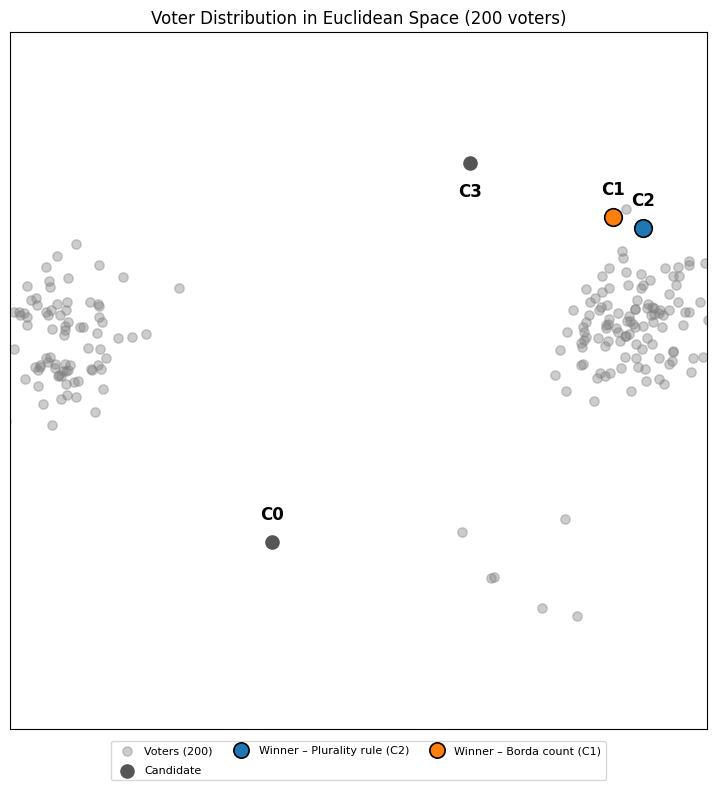

In [7]:
# ---------------------------------------------------------------------------
# Fit gaussian_kde and turn it into a verified scene generator.
# ---------------------------------------------------------------------------
def loo_log_likelihood(features, bw_factor):
    """Leave-one-out mean log-likelihood of a gaussian_kde at a given bandwidth.

    Dropping point i just removes its own kernel, i.e. the K(0) self-term, from
    the all-points density -- closed form, no refitting per point. Use it to pick
    bw_factor instead of trusting Scott/Silverman, which oversmooth in ~19 dims.
    Higher is better.
    """
    data = features.T  # gaussian_kde wants (n_dims, n_samples)
    d, n = data.shape
    kde = gaussian_kde(data, bw_method=bw_factor)
    _, logdet = np.linalg.slogdet(kde.covariance)
    self_term = np.exp(-0.5 * d * np.log(2 * np.pi) - 0.5 * logdet)  # K(0)
    dens = kde(data)
    loo = (n * dens - self_term) / (n - 1)
    return float(np.mean(np.log(np.clip(loo, 1e-300, None))))


# Scan bandwidth factors around Scott's rule and keep the best by LOO-CV.
scott = train_features.shape[0] ** (-1.0 / (train_features.shape[1] + 4))
factors = scott * np.array([0.3, 0.5, 0.7, 1.0, 1.4])
for f in factors:
    print(
        f"bw factor {f:.3f} (scott x{f / scott:.2f}): LOO loglik {loo_log_likelihood(train_features, f):.3f}"
    )
best_factor = float(
    factors[int(np.argmax([loo_log_likelihood(train_features, f) for f in factors]))]
)
print(f"chosen bw factor: {best_factor:.3f}")

kde = gaussian_kde(train_features.T, bw_method=best_factor)


def generate_scene(kde, rng, verify=True, max_tries=50):
    """Sample a feature vector from the KDE, decode it, and (optionally) confirm
    the two rules really disagree on a fresh 200-voter draw.

    Returns (candidate_positions, group_centers, group_weights, voters) or None
    if verification kept failing.
    """
    for _ in range(max_tries):
        feature = kde.resample(1, seed=rng).ravel()
        cand, centers, weights = decode_features(feature)
        voters = sample_voters(centers, weights, N_VOTERS, SPREAD, rng)
        if not verify or winners_differ(cand, voters):
            return cand, centers, weights, voters
    return None


# Quick look at one generated, verified scene through the project's API/plot.
scene = generate_scene(kde, rng)
cand, centers, weights, voters = scene
candidates = [Candidate(id=i, position=p) for i, p in enumerate(cand)]
voter_objs = [Voter(position=v) for v in voters]
result = Election(candidates, voter_objs).compare_strategies(strategies)
print("winners:", {name: c.id for name, c in result.winners().items()})
plot_results(result, bounds=BOUNDS)

KDE reproduction rate: 21.9%   (baseline acceptance: 22.1%)
NN distance  gen->train: 1.947   train->train: 1.720
energy distance  train/train: 0.017   train/KDE: 0.089


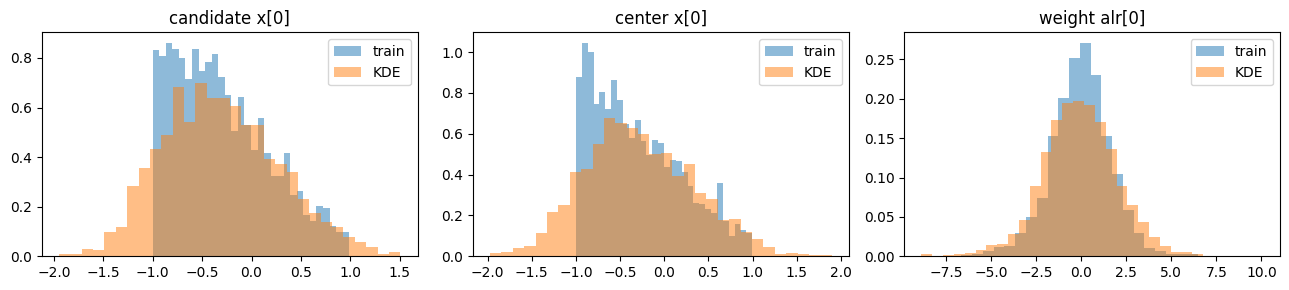

In [8]:
# ---------------------------------------------------------------------------
# Diagnostics: did the KDE "fit" well enough to be a useful proposal?
# ---------------------------------------------------------------------------

# 1) Task metric: how often does a KDE sample actually disagree, on a FRESH
#    voter draw, vs the baseline rejection rate? This is the point of the whole
#    pipeline -- it should be much higher than `acceptance_rate`.
def reproduction_rate(kde, rng, n=1000):
    ok = 0
    for _ in range(n):
        feature = kde.resample(1, seed=rng).ravel()
        cand, centers, weights = decode_features(feature)
        voters = sample_voters(centers, weights, N_VOTERS, SPREAD, rng)
        ok += winners_differ(cand, voters)
    return ok / n


repro = reproduction_rate(kde, rng)
print(
    f"KDE reproduction rate: {repro:.1%}   (baseline acceptance: {acceptance_rate:.1%})"
)

# 2) Memorisation: are KDE samples just jittered copies of training points?
#    generated->train NN distance should be comparable to train->train, not ~0.
gen_features = kde.resample(2000, seed=rng).T
tree = cKDTree(train_features)
d_gen = tree.query(gen_features, k=1)[0]
d_train = tree.query(train_features, k=2)[0][:, 1]  # nearest OTHER train point
print(
    f"NN distance  gen->train: {d_gen.mean():.3f}   train->train: {d_train.mean():.3f}"
)


# 3) Two-sample energy distance: held-out train split vs KDE samples. The
#    train/KDE value should be close to the train/train value.
def energy_distance(a, b, rng, m=400):
    a = a[rng.choice(len(a), min(m, len(a)), replace=False)]
    b = b[rng.choice(len(b), min(m, len(b)), replace=False)]

    def mean_dist(x, y):
        return np.linalg.norm(x[:, None, :] - y[None, :, :], axis=2).mean()

    return 2 * mean_dist(a, b) - mean_dist(a, a) - mean_dist(b, b)


half = len(train_features) // 2
ed_train = energy_distance(train_features[:half], train_features[half:], rng)
ed_gen = energy_distance(train_features[:half], gen_features, rng)
print(f"energy distance  train/train: {ed_train:.3f}   train/KDE: {ed_gen:.3f}")

# 4) Eyeball a few marginals (one candidate coord, one center coord, one weight).
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for ax, j, title in zip(
    axes, [0, 8, 16], ["candidate x[0]", "center x[0]", "weight alr[0]"]
):
    ax.hist(train_features[:, j], bins=30, density=True, alpha=0.5, label="train")
    ax.hist(gen_features[:, j], bins=30, density=True, alpha=0.5, label="KDE")
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.show()